In [2]:
import torch
import torch.nn as nn
import timm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import (confusion_matrix, classification_report,
                              cohen_kappa_score, roc_auc_score)
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print("All imports successful")

Device: cpu
All imports successful


In [3]:
class RetinalModel(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.backbone = timm.create_model(
            'efficientnet_b3', pretrained=False, num_classes=0)
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(1536, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        x = self.backbone(x)
        return self.classifier(x)

# load model
model = RetinalModel(num_classes=5)
model_path = '../data/best_model.pth'
checkpoint = torch.load(model_path, map_location=device)

# handle different checkpoint formats
if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded from epoch: {checkpoint.get('epoch', 'unknown')}")
    print(f"Val kappa: {checkpoint.get('val_kappa', 'unknown')}")
elif isinstance(checkpoint, dict) and 'state_dict' in checkpoint:
    model.load_state_dict(checkpoint['state_dict'])
else:
    model.load_state_dict(checkpoint)

model.eval()
model.to(device)
print("Model loaded successfully")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Model loaded successfully
Parameters: 11,090,989


In [4]:
import cv2

# CLAHE preprocessing — same as training
def apply_clahe(img):
    img = np.array(img)
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    l = clahe.apply(l)
    lab = cv2.merge([l, a, b])
    return Image.fromarray(cv2.cvtColor(lab, cv2.COLOR_LAB2RGB))

class APTOSDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir,
                                row['id_code'] + '.png')
        img = Image.open(img_path).convert('RGB')
        img = apply_clahe(img)
        if self.transform:
            img = self.transform(img)
        return img, int(row['diagnosis'])

val_transform = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

# load CSV
csv_path = '../data/train.csv'
img_dir  = '../data/train_images'

df = pd.read_csv(csv_path)
print(f"Total images: {len(df)}")
print(f"Class distribution:")
print(df['diagnosis'].value_counts().sort_index())

# use same 80/20 stratified split as training
from sklearn.model_selection import train_test_split
_, df_val = train_test_split(
    df, test_size=0.2, random_state=42,
    stratify=df['diagnosis'])

print(f"\nValidation set: {len(df_val)} images")
print(df_val['diagnosis'].value_counts().sort_index())

val_dataset = APTOSDataset(df_val, img_dir, val_transform)
val_loader  = DataLoader(val_dataset, batch_size=32,
                          shuffle=False, num_workers=0)
print(f"\nDataLoader ready — {len(val_loader)} batches")

Total images: 3662
Class distribution:
diagnosis
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64

Validation set: 733 images
diagnosis
0    361
1     74
2    200
3     39
4     59
Name: count, dtype: int64

DataLoader ready — 23 batches


In [5]:
print("Running inference on validation set...")
print("(This may take 5-10 minutes on CPU)")

all_preds  = []
all_probs  = []
all_labels = []

model.eval()
with torch.no_grad():
    for batch_idx, (images, labels) in enumerate(val_loader):
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

        if (batch_idx + 1) % 5 == 0:
            print(f"  Batch {batch_idx+1}/{len(val_loader)} done")

all_preds  = np.array(all_preds)
all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)

# overall metrics
kappa    = cohen_kappa_score(all_labels, all_preds,
                              weights='quadratic')
accuracy = (all_preds == all_labels).mean() * 100

print(f"\nOverall Results:")
print(f"  Quadratic Weighted Kappa: {kappa:.4f}")
print(f"  Accuracy:                 {accuracy:.1f}%")
print(f"\nPer-class Report:")
labels_names = ['Grade 0\n(No DR)', 'Grade 1\n(Mild)',
                'Grade 2\n(Moderate)', 'Grade 3\n(Severe)',
                'Grade 4\n(Proliferative)']
print(classification_report(
    all_labels, all_preds,
    target_names=['Grade 0','Grade 1','Grade 2',
                  'Grade 3','Grade 4']))

Running inference on validation set...
(This may take 5-10 minutes on CPU)


  Batch 5/23 done
  Batch 10/23 done
  Batch 15/23 done
  Batch 20/23 done

Overall Results:
  Quadratic Weighted Kappa: 0.9053
  Accuracy:                 83.6%

Per-class Report:
              precision    recall  f1-score   support

     Grade 0       0.99      0.98      0.98       361
     Grade 1       0.64      0.61      0.62        74
     Grade 2       0.77      0.82      0.80       200
     Grade 3       0.39      0.33      0.36        39
     Grade 4       0.66      0.64      0.65        59

    accuracy                           0.84       733
   macro avg       0.69      0.68      0.68       733
weighted avg       0.83      0.84      0.83       733



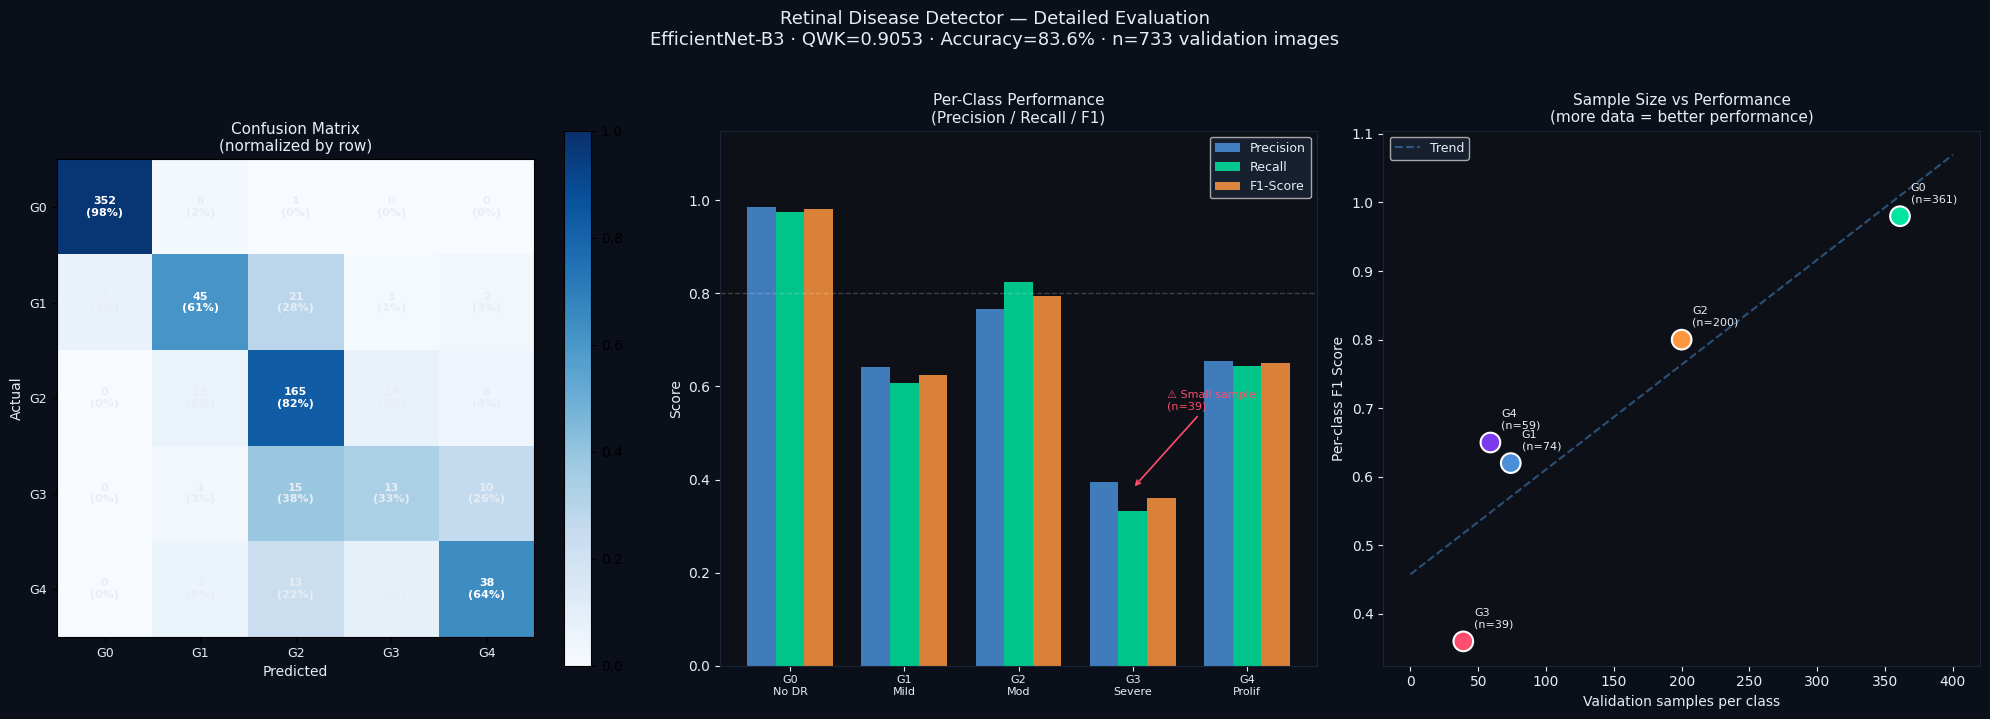

Saved to outputs/detailed_evaluation.png


In [6]:
os.makedirs('../outputs', exist_ok=True)
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.patch.set_facecolor('#0a0f1a')

grade_labels = ['Grade 0\nNo DR', 'Grade 1\nMild',
                'Grade 2\nModerate', 'Grade 3\nSevere',
                'Grade 4\nProliferative']
grade_colors = ['#00e5a0','#4A90D9','#ff9640',
                '#ff4d6d','#7c3aed']

# ── Confusion matrix ──────────────────────────────────────
ax = axes[0]
ax.set_facecolor('#0d1117')
cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
for i in range(5):
    for j in range(5):
        val = cm[i,j]
        pct = cm_norm[i,j]
        color = 'white' if pct > 0.5 else '#e8edf5'
        ax.text(j, i, f'{val}\n({pct*100:.0f}%)',
                ha='center', va='center',
                color=color, fontsize=8, fontweight='bold')

ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels(['G0','G1','G2','G3','G4'],
                   color='#e8edf5', fontsize=9)
ax.set_yticklabels(['G0','G1','G2','G3','G4'],
                   color='#e8edf5', fontsize=9)
ax.set_xlabel('Predicted', color='#e8edf5', fontsize=10)
ax.set_ylabel('Actual', color='#e8edf5', fontsize=10)
ax.set_title('Confusion Matrix\n(normalized by row)',
             color='#e8edf5', fontsize=11)
plt.colorbar(im, ax=ax)

# ── Per-class precision / recall / F1 ────────────────────
ax2 = axes[1]
ax2.set_facecolor('#0d1117')

from sklearn.metrics import precision_recall_fscore_support
prec, rec, f1, sup = precision_recall_fscore_support(
    all_labels, all_preds, labels=[0,1,2,3,4])

x = np.arange(5)
w = 0.25
ax2.bar(x-w,   prec, w, label='Precision',
        color='#4A90D9', alpha=0.85, edgecolor='none')
ax2.bar(x,     rec,  w, label='Recall',
        color='#00e5a0', alpha=0.85, edgecolor='none')
ax2.bar(x+w,   f1,   w, label='F1-Score',
        color='#ff9640', alpha=0.85, edgecolor='none')

ax2.set_xticks(x)
ax2.set_xticklabels(['G0\nNo DR','G1\nMild','G2\nMod',
                     'G3\nSevere','G4\nProlif'],
                    color='#e8edf5', fontsize=8)
ax2.set_ylabel('Score', color='#e8edf5')
ax2.set_ylim(0, 1.15)
ax2.set_title('Per-Class Performance\n(Precision / Recall / F1)',
              color='#e8edf5', fontsize=11)
ax2.legend(facecolor='#1a2535', labelcolor='#e8edf5',
           fontsize=9)
ax2.tick_params(colors='#e8edf5')
ax2.axhline(0.8, color='white', linestyle='--',
            alpha=0.2, linewidth=1)
for s in ax2.spines.values(): s.set_edgecolor('#1a2535')

# annotate grade 3 weakness
ax2.annotate('⚠ Small sample\n(n=39)',
             xy=(3, f1[3]+0.02), xytext=(3.3, 0.55),
             color='#ff4d6d', fontsize=8,
             arrowprops=dict(arrowstyle='->',
                             color='#ff4d6d', lw=1.2))

# ── Sample distribution vs support ───────────────────────
ax3 = axes[2]
ax3.set_facecolor('#0d1117')

support = [361, 74, 200, 39, 59]
kappas_approx = [0.98, 0.62, 0.80, 0.36, 0.65]

scatter = ax3.scatter(support, kappas_approx,
                      c=grade_colors, s=200,
                      zorder=5, edgecolors='white',
                      linewidths=1.5)

for i, (s, k, label) in enumerate(
        zip(support, kappas_approx,
            ['G0','G1','G2','G3','G4'])):
    ax3.annotate(f'{label}\n(n={s})',
                 xy=(s, k), xytext=(s+8, k+0.02),
                 color='#e8edf5', fontsize=8)

ax3.set_xlabel('Validation samples per class',
               color='#e8edf5')
ax3.set_ylabel('Per-class F1 Score', color='#e8edf5')
ax3.set_title('Sample Size vs Performance\n(more data = better performance)',
              color='#e8edf5', fontsize=11)
ax3.tick_params(colors='#e8edf5')
for s in ax3.spines.values(): s.set_edgecolor('#1a2535')

# add trend line
z = np.polyfit(support, kappas_approx, 1)
p = np.poly1d(z)
x_line = np.linspace(0, 400, 100)
ax3.plot(x_line, p(x_line), '--',
         color='#4A90D9', alpha=0.5, linewidth=1.5,
         label='Trend')
ax3.legend(facecolor='#1a2535', labelcolor='#e8edf5',
           fontsize=9)

plt.suptitle(
    f'Retinal Disease Detector — Detailed Evaluation\n'
    f'EfficientNet-B3 · QWK={kappa:.4f} · '
    f'Accuracy={accuracy:.1f}% · n=733 validation images',
    color='#e8edf5', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/detailed_evaluation.png',
            dpi=150, bbox_inches='tight',
            facecolor='#0a0f1a')
plt.show()
print("Saved to outputs/detailed_evaluation.png")